# HunyuanOCR 1.5 on AMD Radeon W7900D

This notebook is an executable product demo, not a benchmark notebook. It combines an immutable ROCm/vLLM runtime, the exact HunyuanOCR-1.5 model payload, original synthetic documents, and an OpenAI-compatible OCR workflow.

**What you will see**

- one-click environment and model validation;
- an on-demand local vLLM service with mandatory `MIOPEN_FIND_MODE=2`;
- Chinese, English, mixed-layout, table, and low-resolution examples;
- rendered Markdown, HTML tables, and LaTeX;
- resumable batch inference, JSON/Markdown export, quality checks, and timing;
- an issue-ready diagnostics report.

> The first empty-cache model startup may take roughly 15 minutes. Subsequent starts reuse the mounted cache.


## 0. Demo Architecture

Jupyter is the container's main process. The service cell starts vLLM in the same container only when it is needed. Both processes use the same immutable model files, while generated caches and outputs remain under `/hunyuanOCR_workspace`.

```text
Browser -> JupyterLab :8892 -> Python kernel
                              |
                              +-> vLLM :18016 -> HunyuanOCR-1.5 -> W7900D
```

The notebook image is derived from:

```text
crpi-a7t9nblyxh55vyd2.cn-shanghai.personal.cr.aliyuncs.com/muzihao2/work@sha256:dc970503ebf22a87aab42a5c6cdb8b8cce5a42685c997b202e6ece6bdf3b1d86
```


In [1]:
from pathlib import Path
import json
import os
import random
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Markdown, display
from PIL import Image

ROOT = Path.cwd().resolve()
required_paths = (
    Path("src/hunyuanocr_demo.py"),
    Path("scripts/start_service.sh"),
    Path("assets/images"),
    Path("outputs"),
)
if not all(path.exists() for path in required_paths):
    raise RuntimeError(
        "Start this notebook from its bundle directory. Keep "
        "hunyuan_ocr_demo.ipynb, src, scripts, assets, and outputs together."
    )
os.environ["HUNYUANOCR_DEMO_ROOT"] = str(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.hunyuanocr_demo import (
    ASSETS_DIR,
    BASE_IMAGE_DIGEST,
    DOC_PARSE_PROMPT,
    MODEL_DIR,
    OUTPUT_DIR,
    archive_outputs,
    batch_infer,
    diagnostic_report,
    ensure_layout,
    infer_image,
    inspect_runtime,
    list_images,
    performance_summary,
    runtime_report,
    save_result,
    service_status,
    start_service,
    stop_service,
    summary_rows,
    tail_service_log,
    write_markdown_report,
)
from src.visualize import visualize_result

random.seed(20260828)
paths = ensure_layout()
paths


{'root': PosixPath('/hunyuanOCR_workspace/demo'),
 'model': PosixPath('/hunyuanOCR_workspace/models/HunyuanOCR'),
 'assets': PosixPath('/hunyuanOCR_workspace/demo/assets/images'),
 'outputs': PosixPath('/hunyuanOCR_workspace/demo/outputs'),
 'json': PosixPath('/hunyuanOCR_workspace/demo/outputs/json'),
 'visualizations': PosixPath('/hunyuanOCR_workspace/demo/outputs/visualizations')}

## 1. Verify the Immutable Runtime

The checks below report the actual container, Python, ROCm/PyTorch, visible GPU, model payload, cache, and output permissions. Files supplied by the mapped notebook bundle are resolved from sibling `src`, `scripts`, `assets`, and `outputs` paths. Image-owned model, runtime, Jupyter, and cache resources remain under the fixed `/hunyuanOCR_workspace` root.


In [2]:
report = runtime_report()
assert report["base_image_digest"] == BASE_IMAGE_DIGEST
assert report["miopen_find_mode"] == "2"
assert report["paths"]["workspace_exists"] is True
assert report["paths"]["bundle_root"] == str(ROOT)
assert report["paths"]["bundle_layout_complete"] is True
assert report["paths"]["model_weight_exists"] is True
assert report["paths"]["model_weight_bytes"] == 2_239_932_512
assert report["paths"]["output_writable"] is True
assert report["torch_probe"]["returncode"] == 0
assert report["torch_probe"]["json"]["cuda_available"] is True
assert report["torch_probe"]["json"]["device_count"] == 1
report


{'base_image_digest': 'sha256:dc970503ebf22a87aab42a5c6cdb8b8cce5a42685c997b202e6ece6bdf3b1d86',
 'notebook_image': 'hunyuanocr-notebook:20260831-root',
 'os': {'PRETTY_NAME': 'Ubuntu 24.04.4 LTS',
  'NAME': 'Ubuntu',
  'VERSION_ID': '24.04',
  'VERSION': '24.04.4 LTS (Noble Numbat)',
  'VERSION_CODENAME': 'noble',
  'ID': 'ubuntu',
  'ID_LIKE': 'debian',
  'HOME_URL': 'https://www.ubuntu.com/',
  'SUPPORT_URL': 'https://help.ubuntu.com/',
  'BUG_REPORT_URL': 'https://bugs.launchpad.net/ubuntu/',
  'PRIVACY_POLICY_URL': 'https://www.ubuntu.com/legal/terms-and-policies/privacy-policy',
  'UBUNTU_CODENAME': 'noble',
  'LOGO': 'ubuntu-logo'},
 'python': '3.12.3',
 'packages': {'torch': '2.10.0+rocm7.2.4.lw.git3d3aa833',
  'transformers': '5.15.0',
  'vllm': '0.27.0+rocm724',
  'openai': '3.0.0',
  'pillow': '12.2.0',
  'requests': '2.34.2',
  'matplotlib': '3.10.9',
  'pandas': '2.3.3',
  'jupyterlab': '4.6.3',
  'ipykernel': '7.3.0',
  'ipywidgets': '8.1.7'},
 'paths': {'demo_root': '/hu

## 2. Inspect HunyuanOCR Entrypoints

The demo inspects the image rather than guessing an inference API. It verifies the embedded model manifest, vLLM executable, supported Python modules, exact model name, and service parameters. The production entrypoint remains the authority for GPU and model validation.


In [3]:
inspection = inspect_runtime()
assert inspection["entrypoint"] == "/hunyuanOCR_workspace/bin/entrypoint.sh"
assert inspection["model_file_count"] == 24
assert inspection["configuration"]["model"] == "tencent/HunyuanOCR"
assert inspection["configuration"]["miopen_find_mode"] == "2"
assert inspection["configuration"]["attention_backend"] in {"ROCM_ATTN", "TRITON_ATTN"}
display(pd.DataFrame(inspection["model_files"]).sort_values("bytes", ascending=False).head(10))
inspection["configuration"]


,path,bytes
18,model.safetensors,2239932512
13,dflash/model.safetensors,362867640
15,dflash/tokenizer.json,9527297
21,tokenizer.json,9527297
5,assets/HyOCR_1_5_teaser.png,1713948
22,tokenizer_config.json,166592
3,LICENSE,16277
4,README.md,14075
12,dflash/dflash.py,8345
9,dflash/README.md,5506


{'model': 'tencent/HunyuanOCR',
 'tensor_parallel': 1,
 'max_model_len': 131072,
 'gpu_memory_utilization': 0.9,
 'miopen_find_mode': '2',
 'attention_backend': 'TRITON_ATTN'}

## 3. Start the OCR Service

This cell starts the validated autoregressive vLLM server with BF16, TP=1, context length 131072, and `MIOPEN_FIND_MODE=2`. The decoder uses the `VLLM_ATTENTION_BACKEND` selected when the container was created (`ROCM_ATTN` by default, or `TRITON_ATTN`); the vision encoder remains on `TORCH_SDPA`. Stop and recreate the container to switch backends. Missing weights, an unavailable GPU, an incorrect architecture, or a path mismatch produces a clear exception with the server log tail.


In [4]:
startup = start_service(timeout_seconds=1800)
assert startup["ready"] is True
assert startup["attention_backend"] == inspection["configuration"]["attention_backend"]
model_info = startup["models"]["data"][0]
assert model_info["id"] == "tencent/HunyuanOCR"
assert model_info["root"] == "/hunyuanOCR_workspace/models/HunyuanOCR"
assert model_info["max_model_len"] == 131072
startup


{'started': True,
 'elapsed_seconds': 127.772,
 'stdout': 'READY: pid=273 port=18016 backend=TRITON_ATTN elapsed_seconds=121',
 'stderr': "curl: (7) Failed to connect to 127.0.0.1 port 18016 after 0 ms: Couldn't connect to server\ncurl: (7) Failed to connect to 127.0.0.1 port 18016 after 0 ms: Couldn't connect to server\ncurl: (7) Failed to connect to 127.0.0.1 port 18016 after 0 ms: Couldn't connect to server\ncurl: (7) Failed to connect to 127.0.0.1 port 18016 after 0 ms: Couldn't connect to server\ncurl: (7) Failed to connect to 127.0.0.1 port 18016 after 0 ms: Couldn't connect to server\ncurl: (7) Failed to connect to 127.0.0.1 port 18016 after 0 ms: Couldn't connect to server\ncurl: (7) Failed to connect to 127.0.0.1 port 18016 after 0 ms: Couldn't connect to server\ncurl: (7) Failed to connect to 127.0.0.1 port 18016 after 0 ms: Couldn't connect to server\ncurl: (7) Failed to connect to 127.0.0.1 port 18016 after 0 ms: Couldn't connect to server\ncurl: (7) Failed to connect to 12

## 4. Synthetic Demo Documents

All samples are original, reproducible images generated by `scripts/generate_assets.py`; no benchmark scans are redistributed. They cover a bilingual two-column page, an invoice-style HTML table, and a rotated low-resolution note.


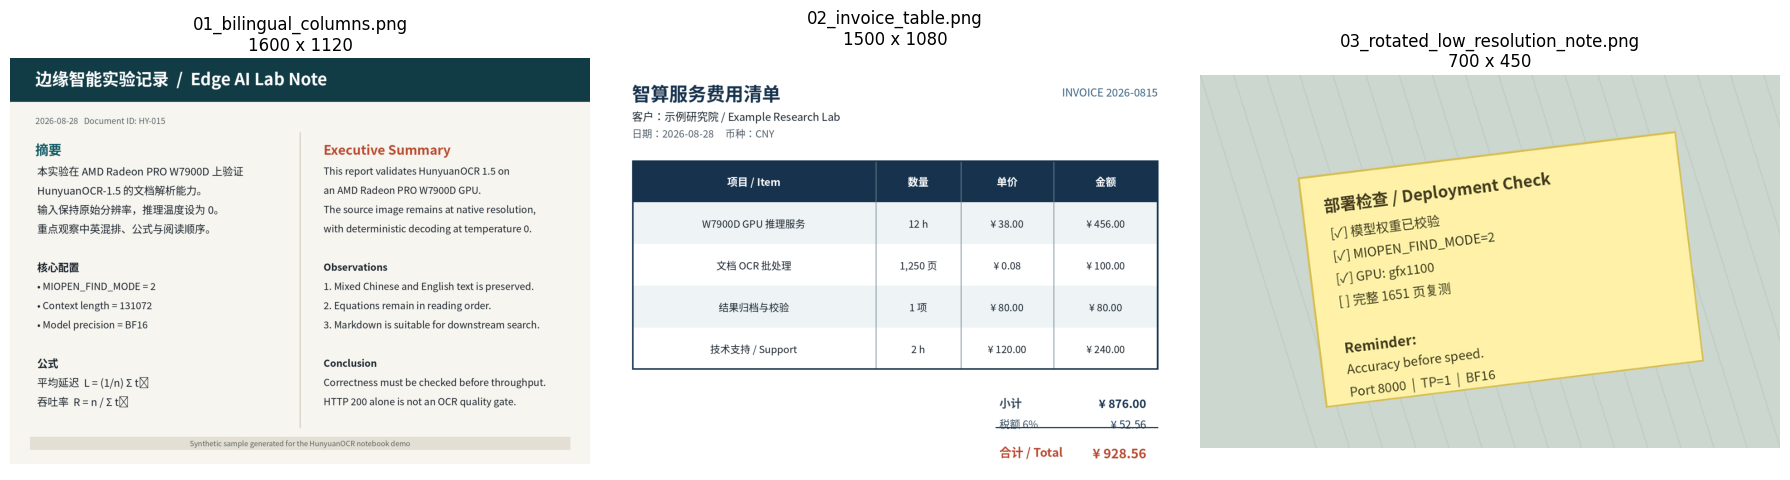

In [5]:
images = list_images()
assert len(images) == 3, images
fig, axes = plt.subplots(1, len(images), figsize=(18, 8))
for axis, path in zip(axes, images):
    with Image.open(path) as image:
        axis.imshow(image)
        axis.set_title(f"{path.name}\n{image.width} x {image.height}")
    axis.axis("off")
plt.tight_layout()
plt.show()


## 5. Single-Page OCR

This cell is a self-contained input-to-output example: it displays the original page, starts or reuses the local vLLM service from inside this notebook, runs HunyuanOCR, and renders the extracted Markdown below. No terminal command is required. The first empty-cache startup can take roughly 15 minutes; later runs reuse the mounted cache.


### Input: original document

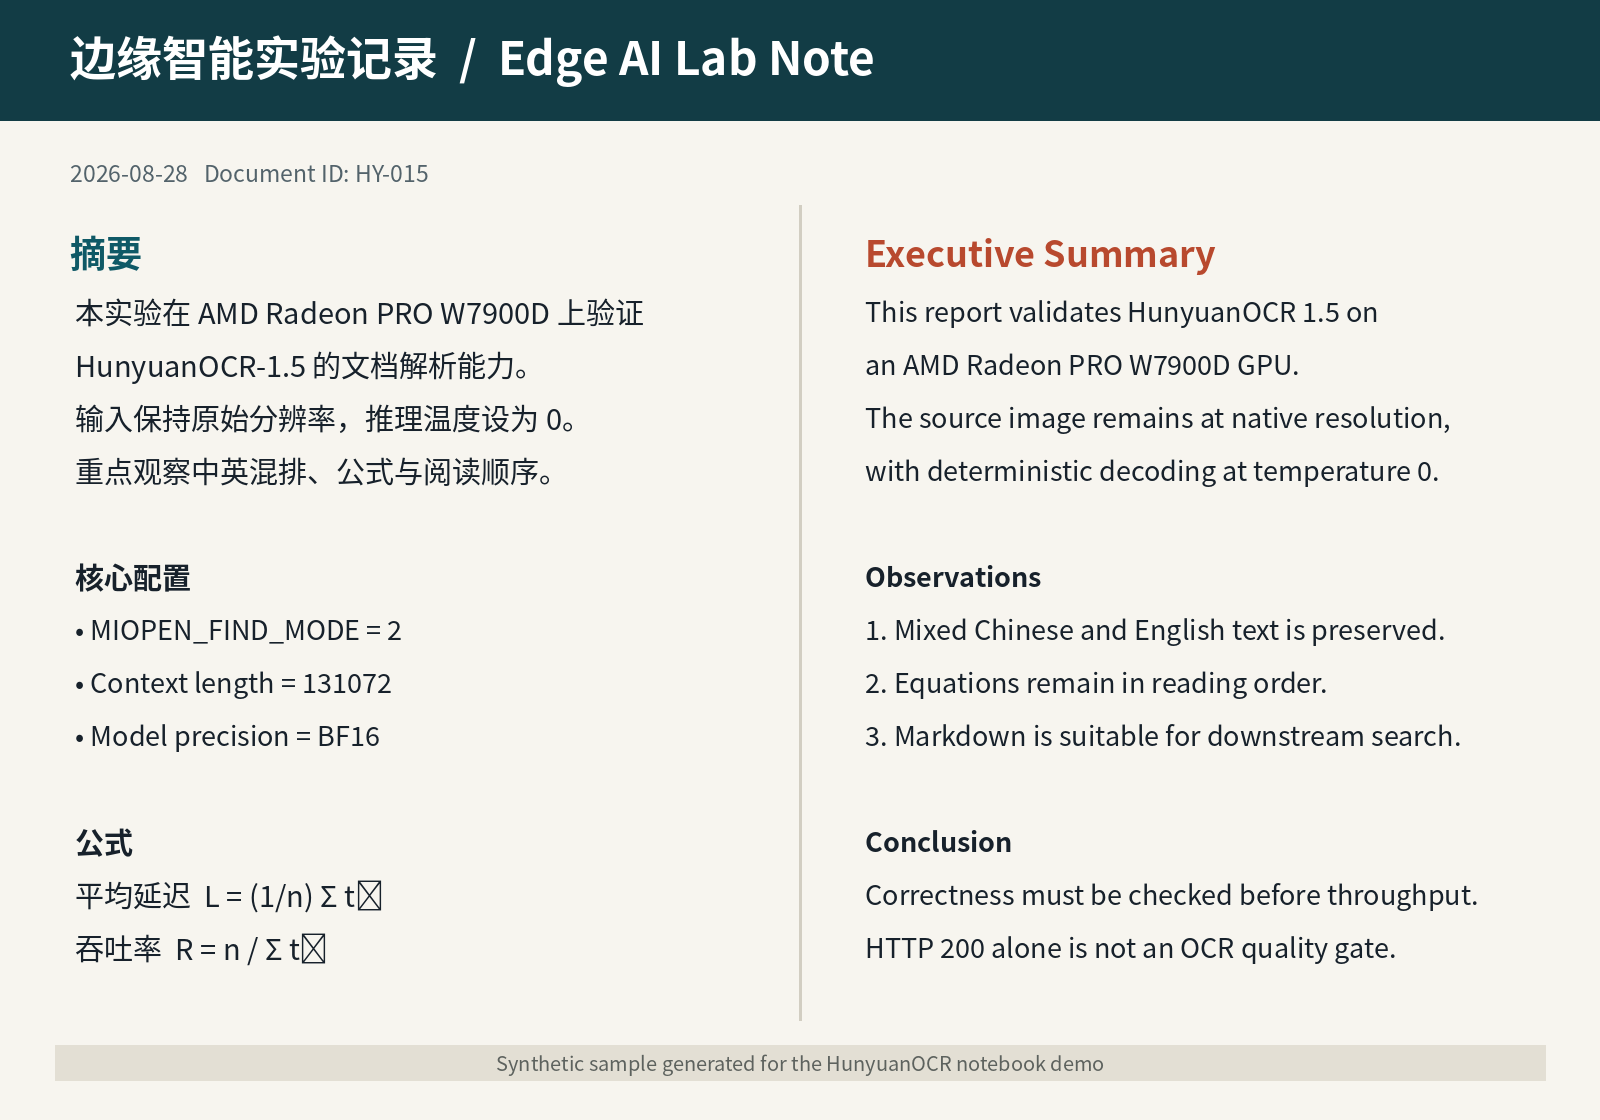

### Output: extracted text

# 边缘智能实验记录 / Edge AI Lab Note

2026-08-28 Document ID: HY-015

## 摘要

本实验在 AMD Radeon PRO W7900D 上验证 HunyuanOCR-1.5 的文档解析能力。

输入保持原始分辨率，推理温度设为 0。

重点观察中英混排、公式与阅读顺序。

## 核心配置

- MIOPEN_FIND_MODE = 2
- Context length = 131072
- Model precision = BF16

## 公式

平均延迟 L = (1/n) $ \Sigma t $ ☒

吞吐率 R = n / $ \Sigma t $ ☒

## Executive Summary

This report validates HunyuanOCR 1.5 on an AMD Radeon PRO W7900D GPU.

The source image remains at native resolution, with deterministic decoding at temperature 0.

## Observations

1. Mixed Chinese and English text is preserved.

2. Equations remain in reading order.

3. Markdown is suitable for downstream search.

## Conclusion

Correctness must be checked before throughput.

HTTP 200 alone is not an OCR quality gate.

{
  "status": "PASS",
  "timing": {
    "latency_seconds": 3.436338
  },
  "usage": {
    "prompt_tokens": 1834,
    "completion_tokens": 244,
    "total_tokens": 2078
  },
  "saved": {
    "json": "/hunyuanOCR_workspace/demo/outputs/json/01_bilingual_columns.json",
    "markdown": "/hunyuanOCR_workspace/demo/outputs/text/01_bilingual_columns.md"
  }
}


In [6]:
single_path = ASSETS_DIR / "01_bilingual_columns.png"
display(Markdown("### Input: original document"))
with Image.open(single_path) as source_image:
    display(source_image.copy())

if not service_status()["ready"]:
    display(Markdown("**Starting HunyuanOCR inside this notebook...**"))
    start_service(timeout_seconds=1800)

single_result = infer_image(single_path)
assert single_result["quality"]["passed"] is True
assert single_result["finish_reason"] == "stop"
saved = save_result(single_result)
display(Markdown("### Output: extracted text"))
display(Markdown(single_result["text"]))
print(json.dumps({
    "status": single_result["status"],
    "timing": single_result["timing"],
    "usage": single_result["usage"],
    "saved": {key: str(value) for key, value in saved.items()},
}, ensure_ascii=False, indent=2))


## 6. Render Markdown, HTML, and LaTeX

HunyuanOCR `doc_parse` returns reading-order Markdown. Jupyter renders headings, tables, and LaTeX directly. The panel below places the source page and rendered OCR text side by side.


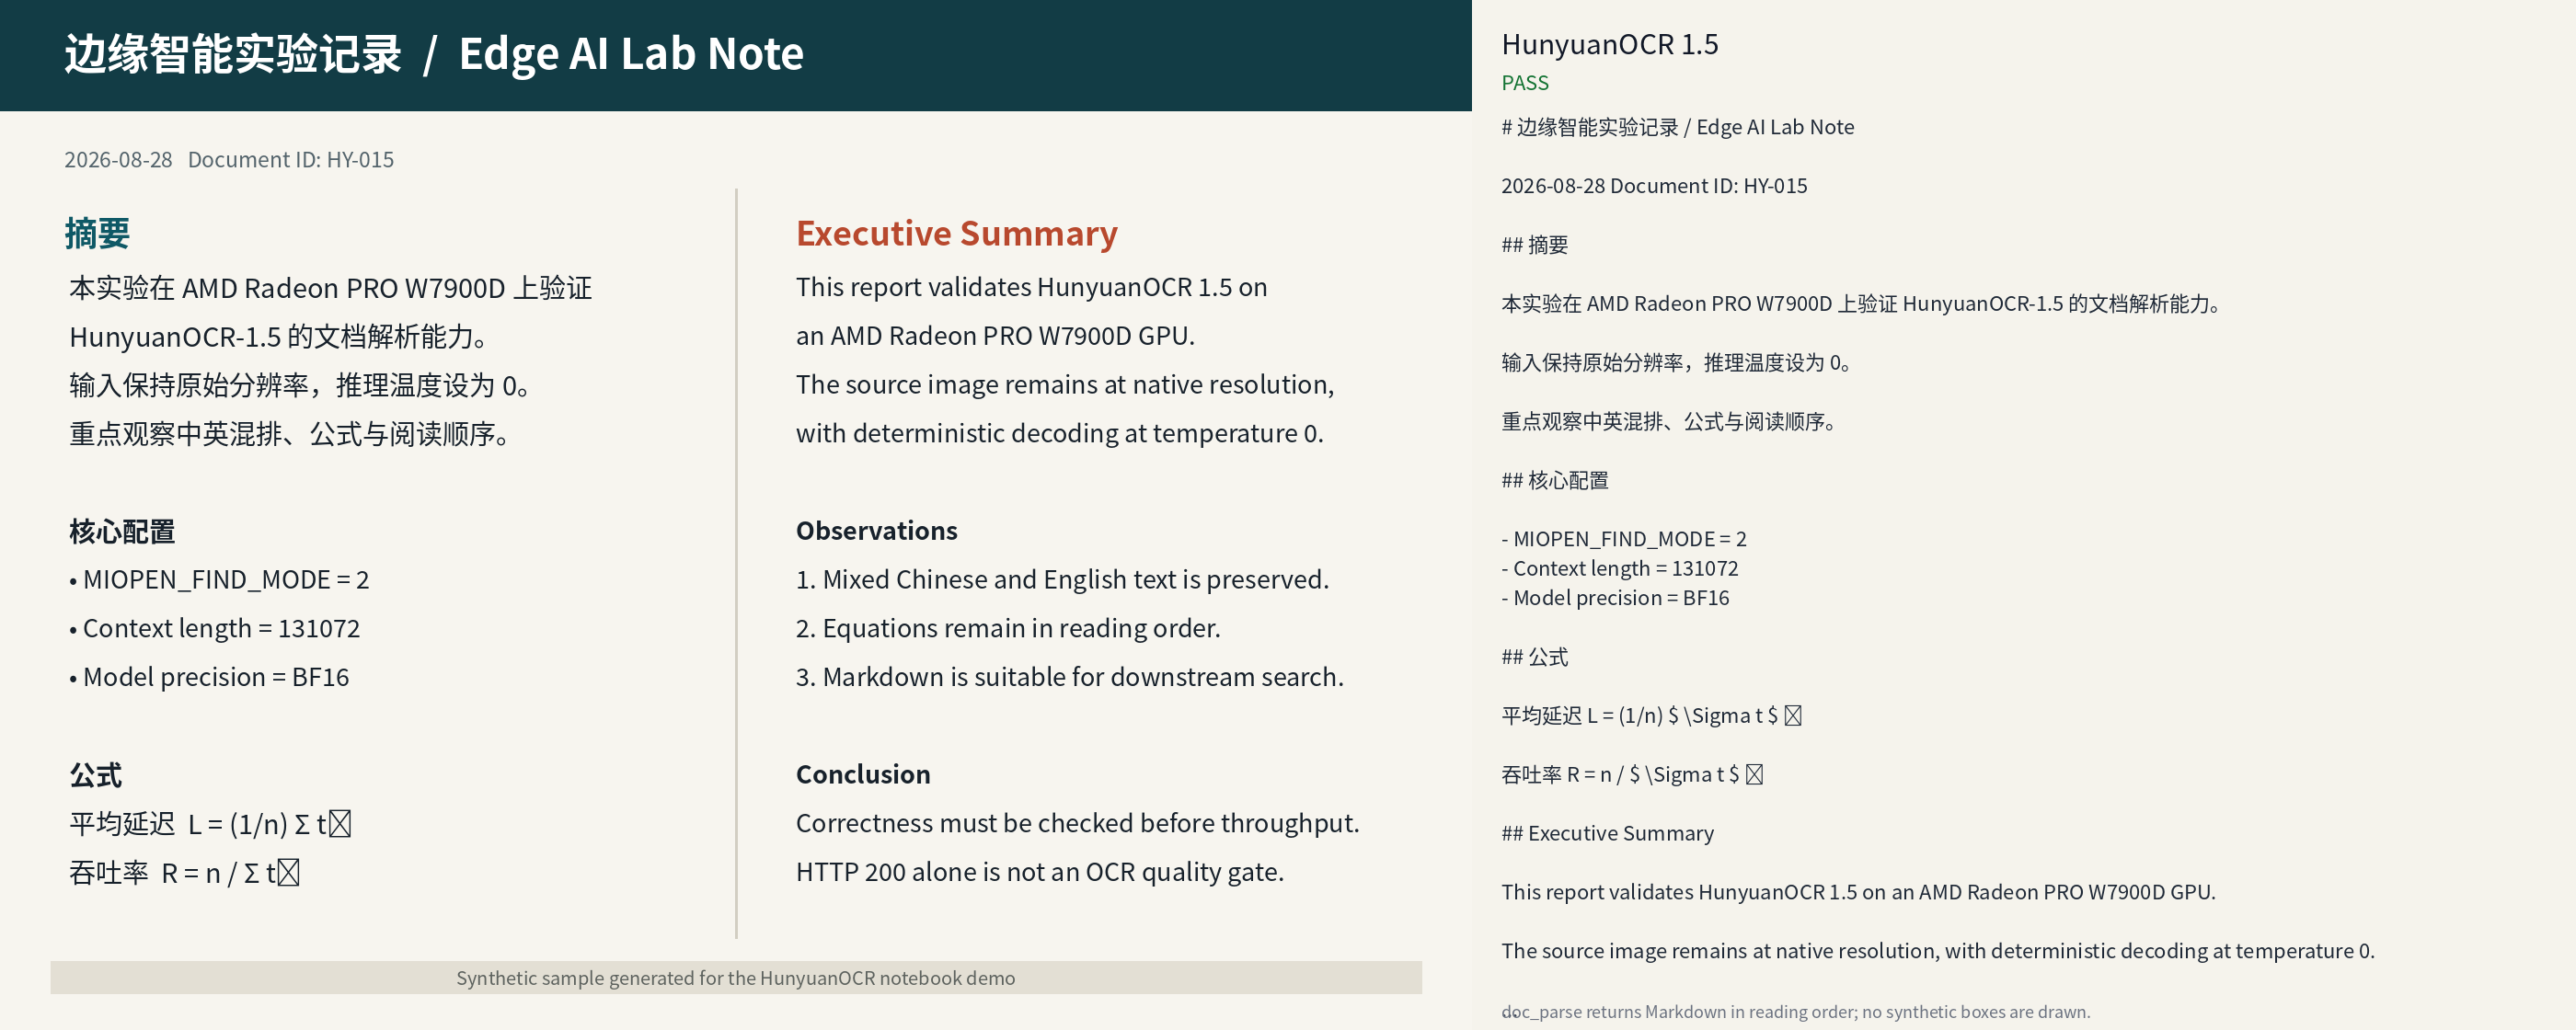

Saved: /hunyuanOCR_workspace/demo/outputs/visualizations/01_bilingual_columns_result.png


In [7]:
visual_path = OUTPUT_DIR / "visualizations" / "01_bilingual_columns_result.png"
visualize_result(single_path, single_result, visual_path)
with Image.open(visual_path) as image:
    display(image)
print(f"Saved: {visual_path}")


### About text boxes and confidence

The validated `doc_parse` endpoint returns Markdown in reading order; it does **not** return calibrated bounding boxes or confidence scores. The demo therefore does not invent them. The normalized `blocks` array exposes `bbox=null` and `confidence=null`. A later notebook can add a separately validated spotting/layout task if spatial output is required.


In [8]:
pd.DataFrame(single_result["blocks"])[["index", "type", "bbox", "confidence", "text"]]


,index,type,bbox,confidence,text
0,1,heading,None,None,# 边缘智能实验记录 / Edge AI Lab Note
1,2,text,None,None,2026-08-28 Document ID: HY-015
2,3,heading,None,None,## 摘要
3,4,text,None,None,本实验在 AMD Radeon PRO W7900D 上验证 HunyuanOCR-1.5 ...
4,5,text,None,None,输入保持原始分辨率，推理温度设为 0。
5,6,text,None,None,重点观察中英混排、公式与阅读顺序。
6,7,heading,None,None,## 核心配置
7,8,text,None,None,- MIOPEN_FIND_MODE = 2\n- Context length = 131...
8,9,heading,None,None,## 公式
9,10,text,None,None,平均延迟 L = (1/n) $ \Sigma t $ ☒


## 7. Complex Layout and Table

The invoice sample exercises mixed Chinese/English text, numeric values, currency symbols, table structure, and reading order. HTML emitted by the model is rendered as part of the returned Markdown.


In [9]:
invoice_path = ASSETS_DIR / "02_invoice_table.png"
invoice_result = infer_image(invoice_path)
assert invoice_result["quality"]["passed"] is True
save_result(invoice_result)
display(Markdown(invoice_result["text"]))
invoice_result["timing"], invoice_result["usage"]


# 智算服务费用清单

客户：示例研究院 / Example Research Lab

日期：2026-08-28 币种：CNY

<table><caption></caption><tr><td>项目 / Item</td><td>数量</td><td>单价</td><td>金额</td></tr><tr><td>W7900D GPU 推理服务</td><td>12 h</td><td>￥38.00</td><td>￥456.00</td></tr><tr><td>文档 OCR 批处理</td><td>1,250 页</td><td>￥0.08</td><td>￥100.00</td></tr><tr><td>结果归档与校验</td><td>1 项</td><td>￥80.00</td><td>￥80.00</td></tr><tr><td>技术支持 / Support</td><td>2 h</td><td>￥120.00</td><td>￥240.00</td></tr></table>

小计     ￥876.00

税额 6%     ￥52.56

合计 / Total     ￥928.56

({'latency_seconds': 2.016696},
 {'prompt_tokens': 1681, 'completion_tokens': 256, 'total_tokens': 1937})

## 8. Batch OCR

The batch runner filters image extensions, catches per-file exceptions, writes each result immediately, and resumes from existing JSON. Set `resume=False` to deliberately re-run every sample.


In [10]:
batch_results = batch_infer(ASSETS_DIR, OUTPUT_DIR, resume=True)
rows = summary_rows(batch_results)
summary = pd.DataFrame(rows)
display(summary)
assert len(summary) == 3
assert summary["quality_pass"].all()
assert (summary["status"] == "PASS").all()


[1/3] resume 01_bilingual_columns.png
[2/3] resume 02_invoice_table.png


[3/3] infer  03_rotated_low_resolution_note.png


,file,size,megapixels,characters,blocks,completion_tokens,latency_seconds,quality_pass,status
0,01_bilingual_columns.png,1600x1120,1.792,761,21,244,3.436338,True,PASS
1,02_invoice_table.png,1500x1080,1.620,513,7,256,2.016696,True,PASS
2,03_rotated_low_resolution_note.png,700x450,0.315,159,8,70,0.454373,True,PASS


## 9. Export Results

Each page has stable JSON and Markdown output. The combined report is human-readable, and the ZIP archive preserves all generated evidence for review or downstream ingestion.


In [11]:
report_path = write_markdown_report(batch_results)
archive_path = archive_outputs()
reloaded = json.loads((OUTPUT_DIR / "json" / "01_bilingual_columns.json").read_text())
assert reloaded["quality"]["passed"] is True
assert report_path.is_file() and archive_path.is_file()
print(f"Markdown report: {report_path}")
print(f"Archive: {archive_path} ({archive_path.stat().st_size:,} bytes)")


Markdown report: /hunyuanOCR_workspace/demo/outputs/hunyuanocr_report.md
Archive: /hunyuanOCR_workspace/demo/hunyuanocr_demo_outputs.zip (305,467 bytes)


## 10. Performance and GPU Memory

The table separates service startup from request latency. Request timing uses the completed HTTP response, while the server owns GPU synchronization. The plot relates submitted megapixels to latency. This three-page demo is descriptive, not an OmniDocBench score.


{'samples': 3,
 'mean_seconds': 1.969136,
 'stdev_seconds': 1.491551,
 'images_per_minute': 30.4702}

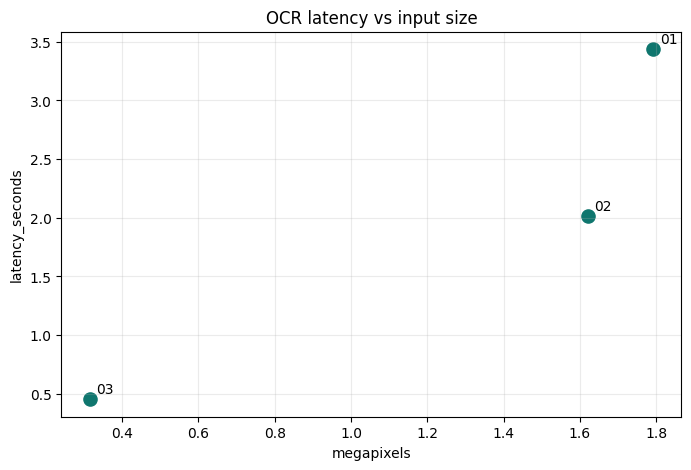

'{"card0": {"VRAM Total Memory (B)": "51522830336", "VRAM Total Used Memory (B)": "30888488960", "Card Series": "AMD Radeon Graphics", "Card Model": "0x744b", "Card Vendor": "Advanced Micro Devices, Inc. [AMD/ATI]", "Card SKU": "D7070910", "Subsystem ID": "0x0e0c", "Device Rev": "0x00", "Node ID": "2", "GUID": "6853", "GFX Version": "gfx1100"}, "card1": {"VRAM Total Memory (B)": "51522830336", "VRAM Total Used Memory (B)": "29298688", "Card Series": "AMD Radeon Graphics", "Card Model": "0x744b", "Card Vendor": "Advanced Micro Devices, Inc. [AMD/ATI]", "Card SKU": "D7070910", "Subsystem ID": "0x0e0c", "Device Rev": "0x00", "Node ID": "3", "GUID": "49884", "GFX Version": "gfx1100"}, "card2": {"VRAM Total Memory (B)": "51522830336", "VRAM Total Used Memory (B)": "29323264", "Card Series": "AMD Radeon Graphics", "Card Model": "0x744b", "Card Vendor": "Advanced Micro Devices, Inc. [AMD/ATI]", "Card SKU": "D7070910", "Subsystem ID": "0x0e0c", "Device Rev": "0x00", "Node ID": "4", "GUID": "60

In [12]:
performance = performance_summary(batch_results)
display(performance)
plot_data = pd.DataFrame(summary_rows(batch_results)).dropna(subset=["megapixels", "latency_seconds"])
axis = plot_data.plot.scatter(x="megapixels", y="latency_seconds", s=90, color="#0f766e", figsize=(8, 5), title="OCR latency vs input size")
for _, row in plot_data.iterrows():
    axis.annotate(row["file"].split("_")[0], (row["megapixels"], row["latency_seconds"]), xytext=(5, 4), textcoords="offset points")
plt.grid(alpha=0.25)
plt.show()
report["rocm_smi"]["stdout"][:2000]


## 11. Quality Gate

HTTP success is not enough. Every output is checked for empty text, coordinate-only collapse, and suspiciously short content. This guard exists because silent numerical corruption can otherwise look like a successful OCR request.


In [13]:
quality_table = pd.DataFrame([
    {"file": result["source"]["name"], **result["quality"]}
    for result in batch_results
])
display(quality_table)
assert quality_table["passed"].all()


,file,empty,coordinate_only,too_short,characters,passed
0,01_bilingual_columns.png,False,False,False,761,True
1,02_invoice_table.png,False,False,False,513,True
2,03_rotated_low_resolution_note.png,False,False,False,159,True


## 12. Reproducibility and Diagnostics

The final cell writes an issue-ready report containing package versions, image digest, GPU/runtime facts, model inventory, service status, configuration, log tail, and common failure guidance for OOM, missing fonts, corrupt images, wrong model paths, or import failures.


In [14]:
diagnostics = diagnostic_report()
diagnostic_path = OUTPUT_DIR / "diagnostics.json"
assert diagnostic_path.is_file()
assert diagnostics["runtime"]["base_image_digest"] == BASE_IMAGE_DIGEST
assert diagnostics["service"]["ready"] is True
print(json.dumps({
    "diagnostics": str(diagnostic_path),
    "base_image_digest": diagnostics["runtime"]["base_image_digest"],
    "model_dir": diagnostics["inspection"]["model_dir"],
    "service_ready": diagnostics["service"]["ready"],
}, indent=2))


{
  "diagnostics": "/hunyuanOCR_workspace/demo/outputs/diagnostics.json",
  "base_image_digest": "sha256:dc970503ebf22a87aab42a5c6cdb8b8cce5a42685c997b202e6ece6bdf3b1d86",
  "model_dir": "/hunyuanOCR_workspace/models/HunyuanOCR",
  "service_ready": true
}


## Optional: Stop the OCR Service

Jupyter can remain open while vLLM is stopped to release GPU memory. Run the next cell only when the interactive OCR portion is finished. `make stop` outside the notebook stops the complete container.


In [15]:
# Uncomment to release GPU memory while keeping JupyterLab running.
# stop_service()
service_status()


{'ready': True,
 'pid': 273,
 'pid_alive': True,
 'pid_state': 'S',
 'attention_backend': 'TRITON_ATTN',
 'models': {'object': 'list',
  'data': [{'id': 'tencent/HunyuanOCR',
    'object': 'model',
    'created': 1788169786,
    'owned_by': 'vllm',
    'root': '/hunyuanOCR_workspace/models/HunyuanOCR',
    'parent': None,
    'max_model_len': 131072,
    'permission': [{'id': 'modelperm-b32f9950e7999740',
      'object': 'model_permission',
      'created': 1788169786,
      'allow_create_engine': False,
      'allow_sampling': True,
      'allow_logprobs': True,
      'allow_search_indices': False,
      'allow_view': True,
      'allow_fine_tuning': False,
      'organization': '*',
      'group': None,
      'is_blocking': False}]}]},
 'error': None}